# KKP Project

#### **a. Nama Dataset dan Sumbernya**  
- **Nama Dataset**: *SR-BH 2020*  
- **Sumber Dataset**: [Harvard Dataverse](https://https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/OGOIXX)  

Dataset ini merupakan kumpulan permintaan HTTP (web requests) yang dikumpulkan selama 12 hari pada Juli 2020 dari server WordPress yang terhubung ke internet. Server menggunakan ModSecurity 2.9.2 dengan OWASP Core Rule Set (CRS) 3.3.0 dalam mode Detection Only, sehingga semua request (baik normal maupun berisi serangan) dicatat tanpa diblokir. Setelah periode pengumpulan selesai, data dilabeli ulang secara manual untuk memastikan keakuratan jenis serangan. Dataset ini dirancang untuk penelitian deteksi serangan web (web attack detection) dengan skema multi-label.

---

#### **b. Jumlah Data**  
- **Jumlah Sampel/Entitas**: 907.814 request
- 525.195 request normal
- 382.619 request anomali/serangan
- **Jumlah Fitur**: 24 fitur (tidak termasuk label)  
- **Label**:
  - **Kolom**: `000 - Normal`, `272 - Protocol Manipulation`, `242 - Code Injection`, `88 - OS Command Injection`, `126 - Path Traversal`, `66 - SQL Injection`, `16 - Dictionary-based Password Attack`, `310 - Scanning for Vulnerable Software`, `153 - Input Data Manipulation`, `248 - Command Injection`, `274 - HTTP Verb Tampering`, `194 - Fake the Source of Data`, `34 - HTTP Response Splitting`, `33 - HTTP Request Smuggling`1.  
  - **Jumlah Kelas**: 13 label serangan + 1 label normal (multi-label classification)  
  - **Deskripsi Label**:
    * `000 - Normal`: Permintaan HTTP normal tanpa indikasi serangan.
    * `272 - Protocol Manipulation`: Manipulasi protokol HTTP.
    * `242 - Code Injection`: Penyisipan kode berbahaya ke dalam aplikasi.
    * `88 - OS Command Injection`: Menjalankan perintah sistem operasi dari input pengguna.
    * `126 - Path Traversal`: Mengakses direktori atau file di luar jalur yang diizinkan.
    * `66 - SQL Injection`: Manipulasi query SQL untuk mengakses/merusak database.
    * `16 - Dictionary-based Password Attack`: Serangan mencoba kata sandi dari daftar kamus.
    * `310 - Scanning for Vulnerable Software`: Pemindaian software rentan pada server.
    * `153 - Input Data Manipulation`: Modifikasi data input untuk tujuan berbahaya.
    * `248 - Command Injection`: Menyuntikkan perintah ke aplikasi.
    * `274 - HTTP Verb Tampering`: Mengubah metode HTTP untuk menghindari filter.
    * `194 - Fake the Source of Data`: Memalsukan sumber data.
    * `34 - HTTP Response Splitting`: Memisahkan respon HTTP untuk tujuan injeksi.
    * `33 - HTTP Request Smuggling`: Memodifikasi permintaan HTTP agar server memprosesnya berbeda.
 

---

#### **c. Format Data**  
- **Format File**: CSV  
- **Struktur Data**:

  * `timestamp`: Waktu request diterima.
  * `src_ip`: Alamat IP sumber (pengirim request).
  * `src_port`: Port sumber dari pengirim request.
  * `dst_ip`: Alamat IP tujuan (server).
  * `dst_port`: Port tujuan (umumnya 80 untuk HTTP).
  * `request_http_method`: Metode HTTP (GET, POST, dll).
  * `request_http_request`: Resource yang diminta (path URL).
  * `request_http_protocol`: Versi protokol HTTP.
  * `request_user_agent`: Informasi perangkat/aplikasi pengirim request.
  * `request_referer`: URL referensi (jika ada).
  * `request_host`: Host tujuan.
  * `request_content_type`: Jenis konten yang dikirim (misal `application/json`).
  * `request_accept`: Format data yang dapat diterima client.
  * `request_accept_encoding`: Encoding data yang dapat diterima (gzip, deflate, dll).
  * `request_connection`: Status koneksi (keep-alive, close).
  * `response_http_protocol`: Versi protokol HTTP pada respon server.
  * `response_http_status_code`: Kode status HTTP.
  * `response_http_status_message`: Pesan status HTTP.
  * `response_content_length`: Ukuran konten respon.
  * **Label kolom**: Indikator serangan (1 = ada, 0 = tidak ada).



## 2. Import Library

Pada tahap ini, kita mengimpor beberapa pustaka python yang dibutuhkan untuk pembangunan model machine learning

In [1]:
# %pip install imblearn
%pip uninstall scikit-learn -y
%pip install scikit-learn==1.4.2
%pip install imbalanced-learn==0.12.3

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 102.5 MB/s eta 0:00:0000:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 5.4 MB/s eta 0:00:0000:01
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sklearn
print(sklearn.__version__)

1.4.2


In [3]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np
import json

# Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Joblib for model persistence
import joblib

# DateTime & Regex Libraries
from datetime import datetime
import re

# GLOBAL SUPPRESSION 

import os
import warnings
import logging

# Hanya tampilkan ERROR untuk log internal TensorFlow/CUDA
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # 0 = semua, 1 = filter INFO, 2 = filter WARNING, 3 = hanya ERROR

# Opsional: matikan optimisasi oneDNN supaya tidak ada extra warning
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Filter warning Python biasa
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Setelah import tensorflow, set logger level
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Filter log dari absl (XLA, CUDA init, Assert op, dsb)
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Opsional: pastikan logging Python standar tidak berisik
logging.getLogger("tensorflow").setLevel(logging.ERROR)

print("✔️ Logging & warnings suppressed successfully")

# Set seed for reproducibility
SEED = 42
# NumPy
np.random.seed(SEED)
# TensorFlow
tf.random.set_seed(SEED)

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve, auc
from sklearn.neural_network import MLPClassifier
import category_encoders as ce
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

# Deep Learning & NLP
import tensorflow as tf
from transformers import BertTokenizer, TFBertModel
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("Libraries imported successfully!")

2025-09-01 19:36:22.786993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756755382.960372      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756755383.009313      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


SUCCESS
Libraries imported successfully!


## 3. Data Loading

Pada tahap ini, kita memuat dataset ke dalam dataframe.

In [4]:
raw_df = pd.read_csv("/kaggle/input//data_capec_multilabel.csv")
raw_df.head()

/tmp/ipykernel_36/2257137883.py:1: DtypeWarning: Columns (9,11,12,13,14,15,16,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("/kaggle/input//data_capec_multilabel.csv")


,timestamp,src_ip,src_port,dst_ip,dst_port,request_http_method,request_http_request,request_http_protocol,request_user_agent,request_referer,...,126 - Path Traversal,66 - SQL Injection,16 - Dictionary-based Password Attack,310 - Scanning for Vulnerable Software,153 - Input Data Manipulation,248 - Command Injection,274 - HTTP Verb Tampering,194 - Fake the Source of Data,34 - HTTP Response Splitting,33 - HTTP Request Smuggling
0,17/Jul/2020:12:23:34 +0100,172.26.0.1,55894.0,172.26.0.4,80.0,GET,/,HTTP/1.1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_3...,NaN,...,0,0,0,0,0,0,0,0,0,0
1,17/Jul/2020:12:23:41 +0100,172.26.0.1,55897.0,172.26.0.4,80.0,GET,/blog/index.php/2020/04/04/voluptatum-reprehen...,HTTP/1.1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; r...,NaN,...,0,0,0,0,0,0,0,0,0,0
2,17/Jul/2020:12:23:51 +0100,172.26.0.1,55901.0,172.26.0.4,80.0,GET,/blog/xmlrpc.php?rsd,HTTP/1.1,Mozilla/4.0 (compatible; MSIE 6.0; Windows NT ...,NaN,...,0,0,0,0,0,0,0,0,0,0
3,17/Jul/2020:12:23:51 +0100,172.26.0.1,55902.0,172.26.0.4,80.0,GET,/,HTTP/1.1,Mozilla/5.0 (Linux; Android 4.2.2; SM-T110 Bui...,NaN,...,0,0,0,0,0,0,0,0,0,0
4,17/Jul/2020:12:23:58 +0100,172.26.0.1,55903.0,172.26.0.4,80.0,GET,/blog/index.php/2020/04/04/nihil-tenetur-et-ad...,HTTP/1.1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_2...,NaN,...,0,0,0,0,0,0,0,0,0,0


## 4. Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Melihat Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
print(f"Dataset shape: {raw_df.shape}")

Dataset shape: (907815, 38)


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907815 entries, 0 to 907814
Data columns (total 38 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               907813 non-null  object 
 1   src_ip                                  907813 non-null  object 
 2   src_port                                907813 non-null  float64
 3   dst_ip                                  907813 non-null  object 
 4   dst_port                                907813 non-null  float64
 5   request_http_method                     907813 non-null  object 
 6   request_http_request                    907813 non-null  object 
 7   request_http_protocol                   907813 non-null  object 
 8   request_user_agent                      903981 non-null  object 
 9   request_referer                         291394 non-null  object 
 10  request_host                            9077

In [7]:
def cek_duplikat(df, columns_to_check, kolom_pengecualian):
    # Hilangkan kolom pengecualian dari daftar kolom yang akan dicek duplikat
    columns_to_check = [col for col in columns_to_check if col not in kolom_pengecualian]
    
    # Cek duplikat di antara kolom yang telah dipilih
    duplikat = df.duplicated(subset=columns_to_check)
    print(f"Jumlah duplikat: {duplikat.sum()}")
    # print(f"Baris duplikat:\n{df[duplikat]}")

# Kolom yang tidak ingin dicek duplikatnya
kolom_pengecualian = ["src_ip", "dst_ip", "dst_port"]

# Penggunaan fungsi
cek_duplikat(raw_df, raw_df.columns.tolist(), kolom_pengecualian)

Jumlah duplikat: 2746


Berdasarkan info data tersebut, dapat dilihat bahwa data ini memiliki 38 kolom. Beberapa kolom terdapat missing value yang perlu ditangani sehingga mencegah model menjadi bias dan menghindari hilangnya informasi seperti kolom request_origin, request_cookie, request_referer, dan lain-lain.

Selain itu, juga perlu diperhatikan tipe data dari setiap kolom. Dari hasil informasi tersebut, diliat bahwa kolom timestamp seharusnya menggunakan tipe data datetime.

Proses penanganan dan penyesuaian pada kolom-kolom tersebut akan dilakukan pada proses data preprocessing nantinya.

Terlihat bahwa pada dataset ini terdapat 2746 duplikat data, sehingga perlu dihapus nantinya. Proses penghapusan juga akan dilakukan pada tahap preprocessing.


=== MISSING VALUES ANALYSIS ===
                          Column  Missing_Count  Missing_Percentage
17          request_do_not_track         907110           99.922341
11                request_origin         906206           99.822761
15       request_accept_language         891955           98.252948
19                  request_body         881072           97.054135
13          request_content_type         879271           96.855747
9                request_referer         616421           67.901610
16       request_accept_encoding         541515           59.650369
14                request_accept         526032           57.944846
12                request_cookie         462553           50.952342
18            request_connection         424955           46.810749
8             request_user_agent           3834            0.422333
23       response_content_length           3292            0.362629
10                  request_host             34            0.003745
0              

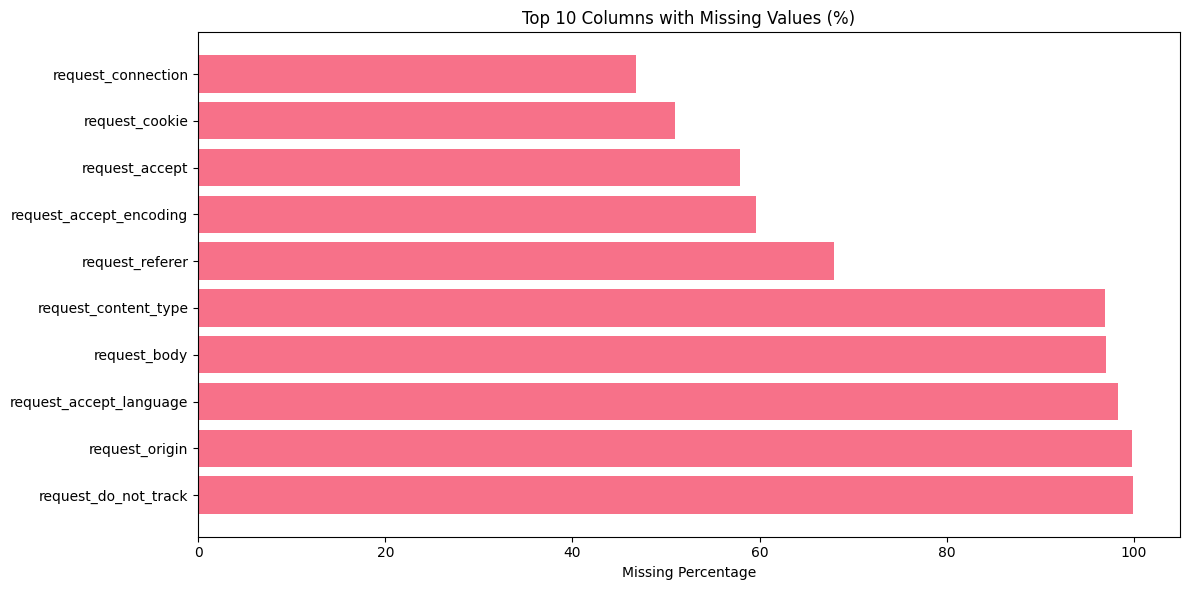

In [8]:
print("\n=== MISSING VALUES ANALYSIS ===")
missing_values = raw_df.isnull().sum()
missing_percentage = (missing_values / len(raw_df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
}).sort_values('Missing_Percentage', ascending=False)

print(missing_df[missing_df.Missing_Count > 0])

# Visualize missing values
plt.figure(figsize=(12, 6))
missing_cols = missing_df[missing_df.Missing_Count > 0].head(10)
plt.barh(missing_cols['Column'], missing_cols['Missing_Percentage'])
plt.title('Top 10 Columns with Missing Values (%)')
plt.xlabel('Missing Percentage')
plt.tight_layout()
plt.show()

Informasi ini menunjukkan bahwa terdapat beberapa kolom dengan nilai yang hilang (missing value). Kolom yang memiliki banyak missing value akan dihapus karena dianggap tidak memberikan informasi yang cukup untuk proses pelatihan model. Sementara itu, untuk data dengan missing value di bawah 5%, hanya baris yang mengandung nilai hilang yang akan dihapus.

Selanjutnya disini kami akan menghapus kolom label yang tidak akan digunakan dan mengubah nama label agar lebih mudah dibaca.

In [9]:
col_drop = [
            '242 - Code Injection', '88 - OS Command Injection', 
            '88 - OS Command Injection', '126 - Path Traversal',
            '310 - Scanning for Vulnerable Software',
            '153 - Input Data Manipulation', '248 - Command Injection',
            '274 - HTTP Verb Tampering', '194 - Fake the Source of Data',
            '34 - HTTP Response Splitting', '33 - HTTP Request Smuggling'            
           ]

raw_df.drop(columns=col_drop, inplace=True)
raw_df.rename(columns={
    "000 - Normal": "Normal",
    "272 - Protocol Manipulation": "Protocol Manipulation",
    "66 - SQL Injection": "SQL Injection",
    "16 - Dictionary-based Password Attack": "Dictionary-based Password Attack"
}, inplace=True)

In [10]:
cat_cols = raw_df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = raw_df.select_dtypes(include=['number']).columns.tolist() 
label_cols = ['Normal', 'Protocol Manipulation', 
        'SQL Injection', 'Dictionary-based Password Attack']

Selanjutnya kami akan melihat distribusi statistik data

In [11]:
raw_df.describe()

,src_port,dst_port,request_do_not_track,response_http_status_code,response_content_length,Normal,Protocol Manipulation,SQL Injection,Dictionary-based Password Attack
count,907813.000000,907813.0,705.0,907813.000000,904523.000000,907815.000000,907815.000000,907815.000000,907815.000000
mean,56749.866303,80.0,1.0,302.851342,17999.002713,0.578526,0.010082,0.275729,0.002035
std,5331.665110,0.0,0.0,100.599167,20200.194933,0.493795,0.099904,0.446881,0.045060
min,1407.000000,80.0,1.0,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51992.000000,80.0,1.0,200.000000,276.000000,0.000000,0.000000,0.000000,0.000000
50%,55747.000000,80.0,1.0,301.000000,21080.000000,1.000000,0.000000,0.000000,0.000000
75%,62110.000000,80.0,1.0,404.000000,25174.000000,1.000000,0.000000,1.000000,0.000000
max,65534.000000,80.0,1.0,501.000000,236440.000000,1.000000,1.000000,1.000000,1.000000


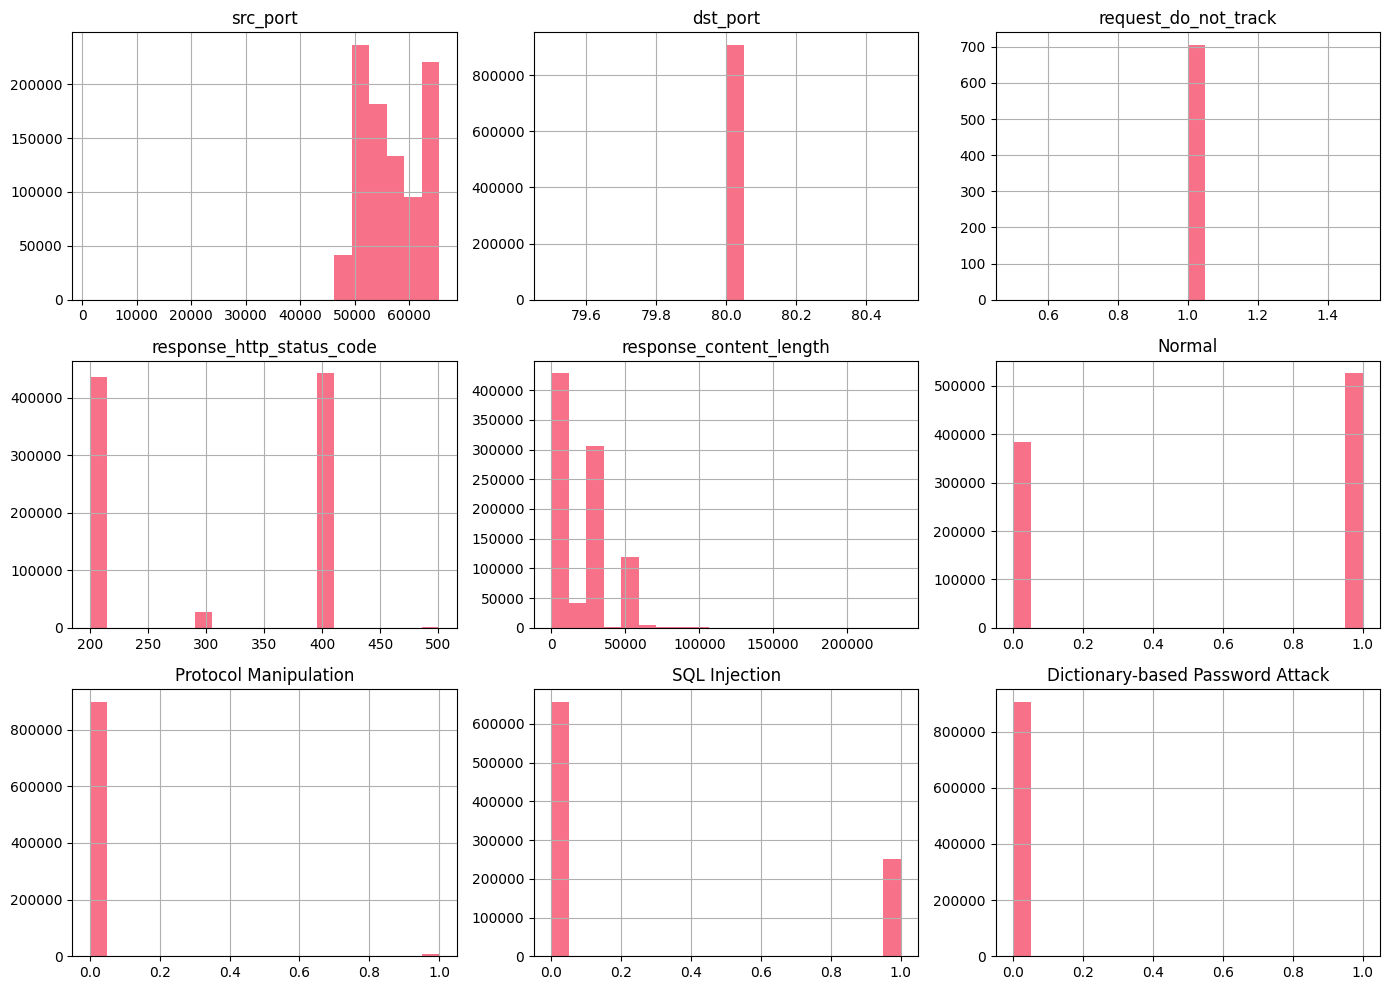

In [12]:
# Menampilkan distribusi kolom numerik

# Plot histogram untuk setiap kolom numerik
raw_df[num_cols].hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

Informasi ini menunjukkan bahwa pada kolom *dst_port* dan *request_do_not_track* tidak memiliki variasi (tidak informatif) karena data unik hanya 1 sehingga kolom ini tidak akan digunakan dalam proses pelatihan model. 

In [13]:
raw_df.describe(include='object')

,timestamp,src_ip,dst_ip,request_http_method,request_http_request,request_http_protocol,request_user_agent,request_referer,request_host,request_origin,request_cookie,request_content_type,request_accept,request_accept_language,request_accept_encoding,request_connection,request_body,response_http_protocol,response_http_status_message
count,907813,907813,907813,907813,907813,907813,903981,291394,907781,1609,445262,28544,381783,15860,366300,482860,26743,907813,907813
unique,201533,1,1,17,350340,2,2001,2144,8,61,11550,322,74,67,5,4,23762,2,13
top,17/Jul/2020:20:06:08 +0200,172.26.0.1,172.26.0.4,GET,/,HTTP/1.1,Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko...,http://test-site.com/,test-site.com,https://test-site.com,wordpress_test_cookie=WP+Cookie+check,application/x-www-form-urlencoded,*/*,"en-US,en;q=0.5","gzip, deflate",keep-alive,comment=&submit=Post+Comment&comment_post_ID=5...,HTTP/1.1,OK
freq,103,907813,907813,869268,299009,907082,506816,51185,903751,1522,41848,26310,365990,15645,366028,380132,843,907522,436532


Dari hasil tersebut, diperoleh bahwa kolom src_ip dan dst_ip hanya memiliki satu nilai unik (tidak informatif), sehingga kolom-kolom ini tidak akan digunakan dalam pelatihan. Namun, kolom src_ip dapat dimanfaatkan untuk menghasilkan fitur request_rate per IP dalam rentang waktu menit/detik

Sedangkan untuk *request_http_method* terdapat terlalu banyak variasi (GET, HEAD, POST, PUT, dll) sehingga diperlukan pemilihan 3 atau 4 saja yang terbanyak atau yang memiliki korelasi tinggi dengan label.

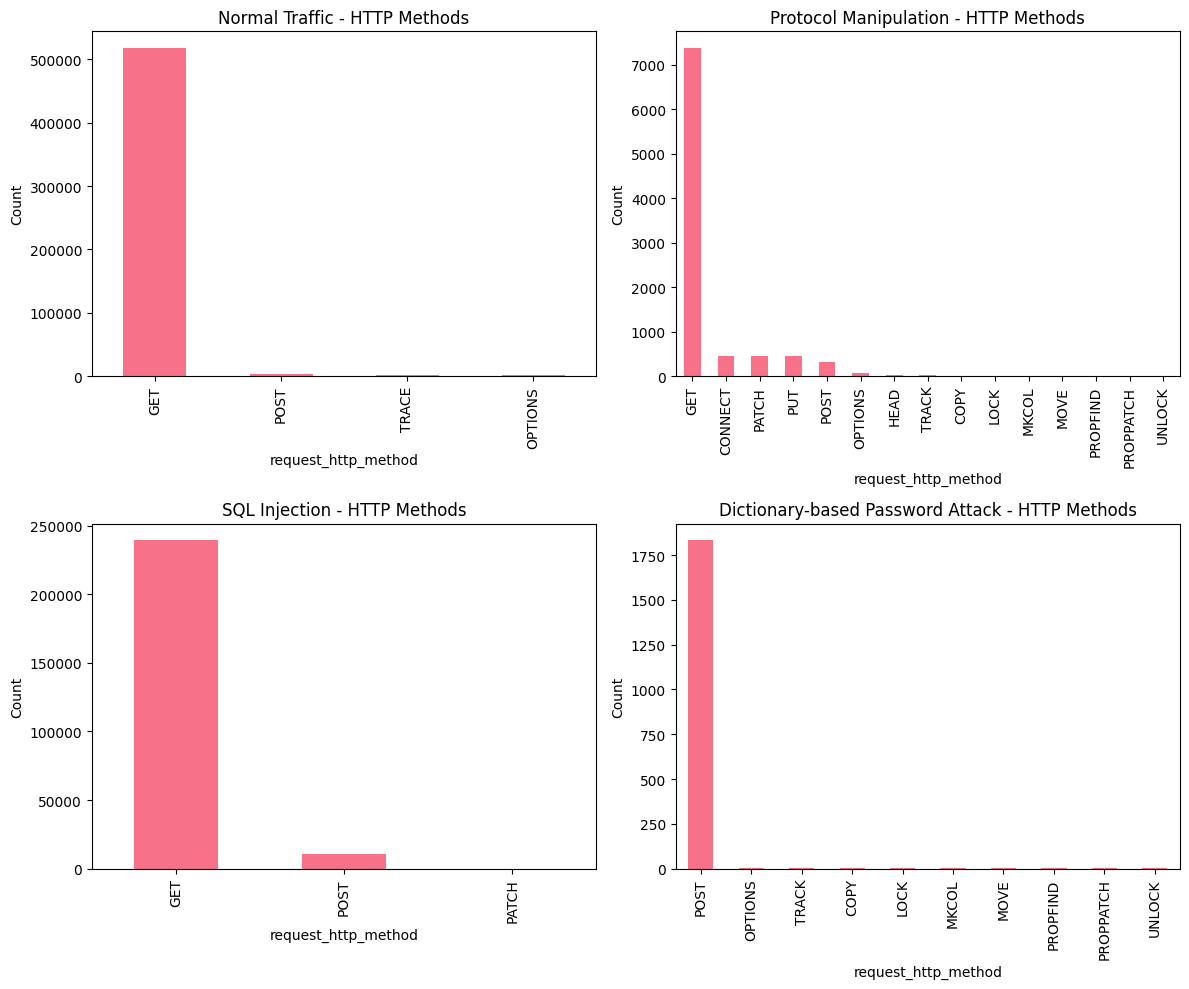

,Normal,Protocol Manipulation,SQL Injection,Dictionary-based Password Attack
request_http_method,,,,
CONNECT,0.0,453.0,0.0,0.0
COPY,0.0,3.0,0.0,1.0
GET,518217.0,7377.0,239497.0,0.0
HEAD,0.0,25.0,0.0,0.0
LOCK,0.0,3.0,0.0,1.0
MKCOL,0.0,3.0,0.0,1.0
MOVE,0.0,3.0,0.0,1.0
OPTIONS,921.0,67.0,0.0,5.0
PATCH,0.0,440.0,2.0,0.0


In [14]:
# Memastikan bahwa jenis serangan adalah kategori yang terpisah
attack_types = ['Normal', 'Protocol Manipulation', 'SQL Injection', 'Dictionary-based Password Attack']

# Filter data berdasarkan jenis serangan
normal_data = raw_df[raw_df['Normal'] == 1]
protocol_manipulation_data = raw_df[raw_df['Protocol Manipulation'] == 1]
sql_injection_data = raw_df[raw_df['SQL Injection'] == 1]
password_attack_data = raw_df[raw_df['Dictionary-based Password Attack'] == 1]

# Hitung distribusi HTTP Method per attack type
normal_method_counts = normal_data['request_http_method'].value_counts()
protocol_manipulation_method_counts = protocol_manipulation_data['request_http_method'].value_counts()
sql_injection_method_counts = sql_injection_data['request_http_method'].value_counts()
password_attack_method_counts = password_attack_data['request_http_method'].value_counts()

# Membuat subplots untuk visualisasi
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Normal traffic
normal_method_counts.plot(kind='bar', ax=axes[0, 0], title='Normal Traffic - HTTP Methods')
axes[0, 0].set_ylabel('Count')

# Protocol Manipulation
protocol_manipulation_method_counts.plot(kind='bar', ax=axes[0, 1], title='Protocol Manipulation - HTTP Methods')
axes[0, 1].set_ylabel('Count')

# SQL Injection
sql_injection_method_counts.plot(kind='bar', ax=axes[1, 0], title='SQL Injection - HTTP Methods')
axes[1, 0].set_ylabel('Count')

# Dictionary-based Password Attack
password_attack_method_counts.plot(kind='bar', ax=axes[1, 1], title='Dictionary-based Password Attack - HTTP Methods')
axes[1, 1].set_ylabel('Count')

# Menampilkan plot
plt.tight_layout()
plt.show()

# Menggabungkan hasil distribusi menjadi satu dataframe
method_distribution = pd.DataFrame({
    'Normal': normal_method_counts,
    'Protocol Manipulation': protocol_manipulation_method_counts,
    'SQL Injection': sql_injection_method_counts,
    'Dictionary-based Password Attack': password_attack_method_counts
}).fillna(0)  # Mengisi NaN dengan 0 jika tidak ada method untuk serangan tertentu

# Menampilkan tabel distribusi
method_distribution

Dari informasi tersebut didapatkan bahwa method GET dan POST yang memiliki korelasi tinggi dengan label. Selain itu juga kami akan menggunakan method PUT yang memiliki korelasi pada label serangan Protocol Manipulation.

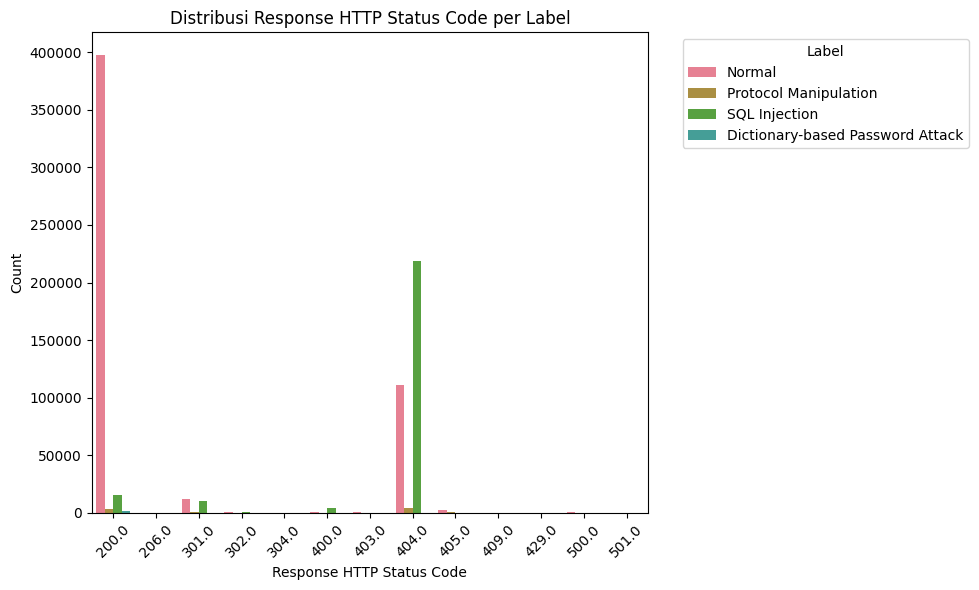

In [15]:
# Untuk menyimpan distribusi kode status per label
distribution = {}

# Loop untuk tiap label
for label in label_cols:
    # Filter data sesuai dengan label
    filtered_data = raw_df[raw_df[label] == 1]
    
    # Hitung distribusi response_http_status_code untuk label tertentu
    status_code_distribution = filtered_data['response_http_status_code'].value_counts().reset_index()
    status_code_distribution.columns = ['response_http_status_code', 'count']
    
    # Menambahkan label
    status_code_distribution['label'] = label
    
    # Gabungkan distribusi
    distribution[label] = status_code_distribution

# Menggabungkan semua distribusi untuk visualisasi
final_distribution = pd.concat(distribution.values())

# Visualisasi dengan seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=final_distribution, x='response_http_status_code', y='count', hue='label')

# Menambahkan label dan judul
plt.title("Distribusi Response HTTP Status Code per Label")
plt.xlabel("Response HTTP Status Code")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Memindahkan legend ke luar plot
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# Menampilkan grafik
plt.tight_layout()
plt.show()

Dari informasi ini menunjukkan bahwa response HTTP status code yang memiliki korelasi tinggi terhadap label adalah code 200 dan 404.

Selanjutnya kami akan melihat distribusi antara label normal dan serangan.

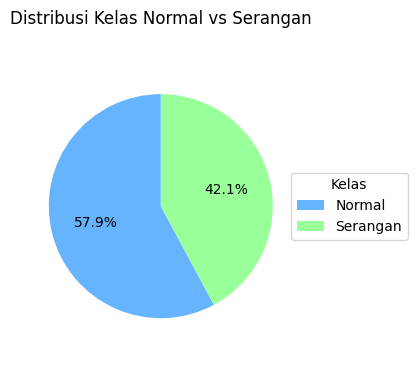

In [16]:
# Visualisasi Ketidakseimbangan Kelas - Versi Lebih Rapi
class_distribution = raw_df['Normal'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(4, 4))  # Ukuran lebih kecil
colors = ['#66b3ff', '#99ff99']  # Biru dan hijau
labels = ['Normal', 'Serangan']

# Pie chart
wedges, texts, autotexts = ax.pie(
    class_distribution,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10}
)

# Legend di luar chart
ax.legend(
    wedges,
    labels,
    title="Kelas",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.set_title('Distribusi Kelas Normal vs Serangan', fontsize=12)
ax.axis('equal')  # Pastikan pie chart bulat
plt.tight_layout()
plt.show()

Dari diagram lingkaran tersebut, terlihat bahwa 57,9% merupakan permintaan normal, sementara 42,1% merupakan permintaan yang teridentifikasi sebagai serangan.

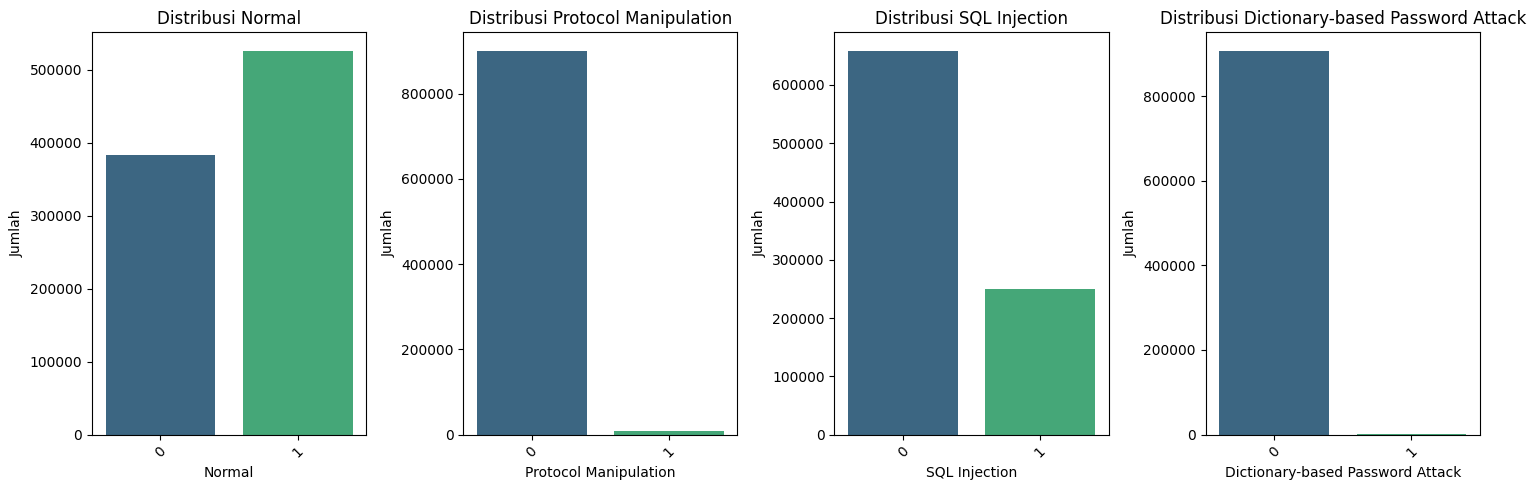

In [17]:
# Distribusi untuk Label
# Menentukan ukuran figur dan jumlah subplot untuk kolom kategorikal
n_categorical_plots = len(label_cols)
fig2, axes2 = plt.subplots(1, n_categorical_plots, figsize=(15, 5))

# Membuat countplot untuk kolom kategorikal
for i, col in enumerate(label_cols):
    sns.countplot(data=raw_df, x=col, ax=axes2[i], palette='viridis')
    axes2[i].set_title(f'Distribusi {col}')
    axes2[i].set_xlabel(col)
    axes2[i].set_ylabel('Jumlah')
    axes2[i].tick_params(axis='x', rotation=45)

# Menampilkan plot
plt.tight_layout()
plt.show()

Dari dari diagram tersebut, terlihat bahwa distribusi antara yes(1) dan no(0) untuk setiap label serangan. Semua label serangan memiliki gap yang sangat jauh antara 0 dan 1 sehingga perlu dilakukan penanganan agar data tidak menjadi bias ke satu sisi.

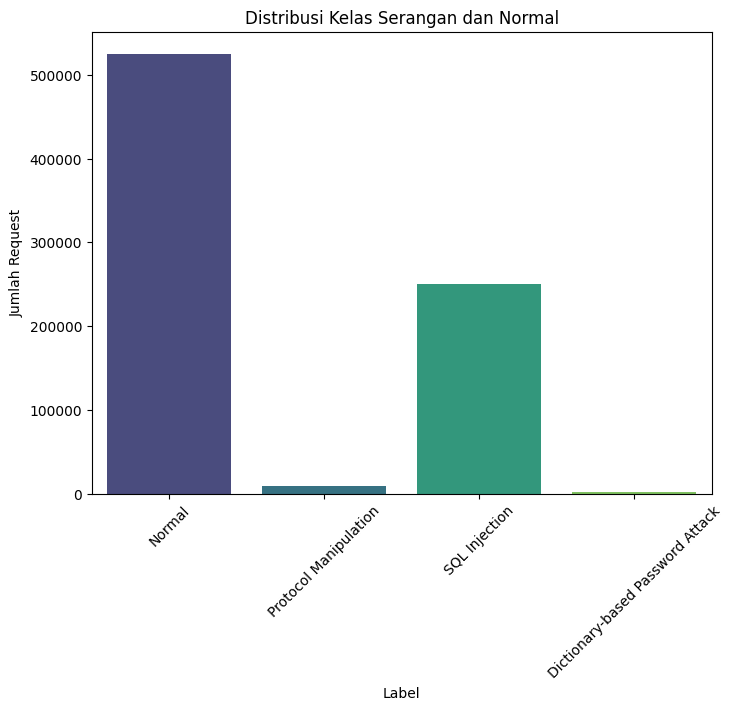

In [18]:
# Distribusi Label Kelas
label_counts = raw_df[label_cols].sum()
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribusi Kelas Serangan dan Normal')
plt.xlabel('Label')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=45)
plt.show()

Diagram batang ini menunjukkan informasi distribusi setiap label dengan seluruh data dari dataset. Terlihat bahwa label serangan "SQL Injection" adalah terbanyak diantara label serangan lainnya.

In [19]:
print("=== IDENTIFYING LABEL COLUMNS ===")

label_columns = label_cols
feature_columns = cat_cols + num_cols

print("Jumlah Data: ", len(raw_df))
print(f"Found {len(label_columns)} label columns:")
for label in label_columns:
    count = raw_df[label].sum() if label in raw_df.columns else 0
    print(f"  - {label}: {count} positive cases")

=== IDENTIFYING LABEL COLUMNS ===
Jumlah Data:  907815
Found 4 label columns:
  - Normal: 525195 positive cases
  - Protocol Manipulation: 9153 positive cases
  - SQL Injection: 250311 positive cases
  - Dictionary-based Password Attack: 1847 positive cases


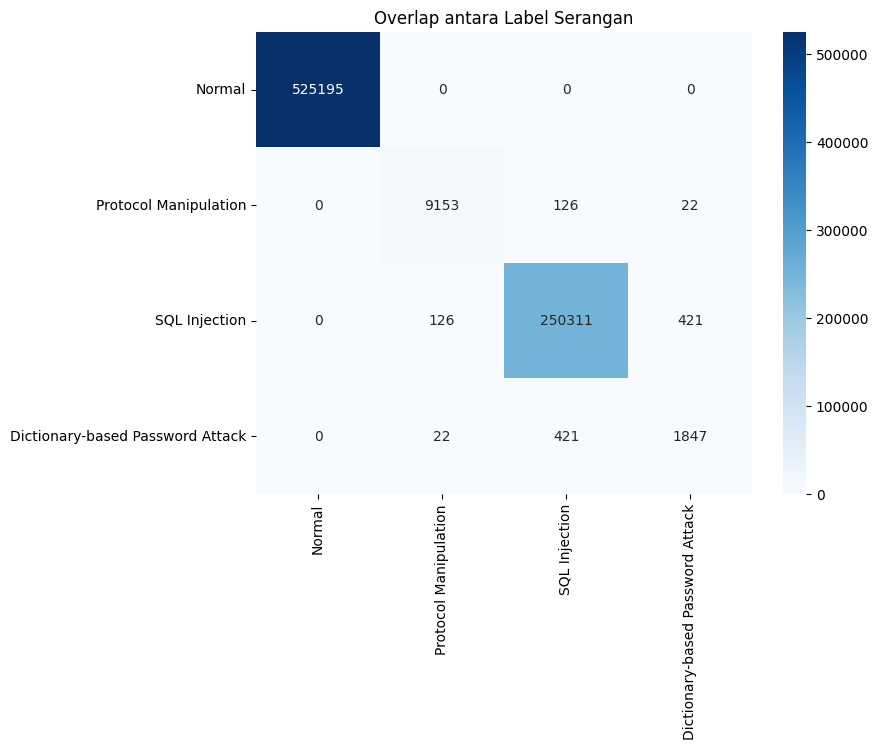

In [20]:
# Distribusi Label Multi-kelas (Overlap antara Serangan)
overlap_matrix = raw_df[label_cols].T.dot(raw_df[label_cols])
plt.figure(figsize=(8, 6))
sns.heatmap(overlap_matrix, annot=True, cmap='Blues', fmt='d')
plt.title('Overlap antara Label Serangan')
plt.show()

Dari hasil heatmap tersebut, terlihat bahwa terdapat adanya hubungan (korelasi) antar label yang artinya satu request dapat dikategorikan lebih dari satu label serangan.

## 5. Preprocessing

Proses pada tahap preprocessing yang akan kami lakukan adalah sebagai berikut.
- Missing value Handling
- Remove Duplicate Data
- Preprocessing Fitur

#### Data Copy

In [21]:
print("=== CREATING DATA COPY ===")
# Create copy for preprocessing to preserve original data
df = raw_df.copy()
print(f"Created copy of original data: {df.shape}")

=== CREATING DATA COPY ===
Created copy of original data: (907815, 28)


#### Drop Kolom 

In [22]:
# Define columns to drop based on analysis
columns_to_drop = [
    'request_do_not_track',
    'request_origin', 
    'request_accept_language',
    'request_body',
    'request_content_type',
    'request_referer',
    'request_accept_encoding',
    'request_accept',
    'request_cookie',
    'request_connection'
]

In [23]:
# Check which columns exist before dropping
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
missing_cols = [col for col in columns_to_drop if col not in df.columns]

print(f"Columns found and will be dropped: {len(existing_cols_to_drop)}")
for col in existing_cols_to_drop:
    print(f"  - {col}")

if missing_cols:
    print(f"Columns not found in dataset: {missing_cols}")

# Drop the columns
if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop)
    print(f"Dropped {len(existing_cols_to_drop)} columns")
    print(f"New dataset shape: {df.shape}")
else:
    print("No columns to drop")

# Show remaining columns
print(f"\nRemaining columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Columns found and will be dropped: 10
  - request_do_not_track
  - request_origin
  - request_accept_language
  - request_body
  - request_content_type
  - request_referer
  - request_accept_encoding
  - request_accept
  - request_cookie
  - request_connection
Dropped 10 columns
New dataset shape: (907815, 18)

Remaining columns (18):
   1. timestamp
   2. src_ip
   3. src_port
   4. dst_ip
   5. dst_port
   6. request_http_method
   7. request_http_request
   8. request_http_protocol
   9. request_user_agent
  10. request_host
  11. response_http_protocol
  12. response_http_status_code
  13. response_http_status_message
  14. response_content_length
  15. Normal
  16. Protocol Manipulation
  17. SQL Injection
  18. Dictionary-based Password Attack


#### Handling Missing Value 

In [24]:
# Info sebelum
print("=== INFO SEBELUM ===")
print(df.isna().sum())
print(f"Shape sebelum: {df.shape}")

=== INFO SEBELUM ===
timestamp                              2
src_ip                                 2
src_port                               2
dst_ip                                 2
dst_port                               2
request_http_method                    2
request_http_request                   2
request_http_protocol                  2
request_user_agent                  3834
request_host                          34
response_http_protocol                 2
response_http_status_code              2
response_http_status_message           2
response_content_length             3292
Normal                                 0
Protocol Manipulation                  0
SQL Injection                          0
Dictionary-based Password Attack       0
dtype: int64
Shape sebelum: (907815, 18)


In [25]:
# Mengisi missing value pada kolom 'request_user_agent' dengan 'unknown'
df['request_user_agent'] = df['request_user_agent'].fillna('unknown')

# Mengisi missing value pada kolom 'response_content_length' dengan mode
mode_content_length = df['response_content_length'].mode()[0]
df['response_content_length'] = df['response_content_length'].fillna(mode_content_length)

In [26]:
# Drop NA
df.dropna(inplace=True)

# Info sesudah
print("\n=== INFO SESUDAH ===")
print(df.isna().sum())
print(f"Shape sesudah: {df.shape}")


=== INFO SESUDAH ===
timestamp                           0
src_ip                              0
src_port                            0
dst_ip                              0
dst_port                            0
request_http_method                 0
request_http_request                0
request_http_protocol               0
request_user_agent                  0
request_host                        0
response_http_protocol              0
response_http_status_code           0
response_http_status_message        0
response_content_length             0
Normal                              0
Protocol Manipulation               0
SQL Injection                       0
Dictionary-based Password Attack    0
dtype: int64
Shape sesudah: (907781, 18)


#### Handling Duplicate

In [27]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [28]:
# Hapus data overlap
# Membuat mask untuk mendeteksi data yang memiliki lebih dari satu label serangan
target_cols = ["Normal", "Protocol Manipulation", "SQL Injection", "Dictionary-based Password Attack"]
overlap_mask = df[target_cols].sum(axis=1) > 1

# Menghapus data yang memiliki lebih dari satu label serangan
df = df[~overlap_mask]

# Menampilkan jumlah record yang dihapus dan ukuran baru DataFrame
print(f"Removed {overlap_mask.sum()} overlapping samples. New shape: {df.shape}")

Removed 475 overlapping samples. New shape: (885361, 18)


#### Combined Label

In [29]:
# =========================
# Membuat combined_label dalam bentuk string
# =========================
def create_combined_label(row):
    if row['Normal'] == 1:
        return 'Normal'
    elif row['Protocol Manipulation'] == 1:
        return 'Protocol Manipulation'
    elif row['SQL Injection'] == 1:
        return 'SQL Injection'
    elif row['Dictionary-based Password Attack'] == 1:
        return 'Dictionary-based Password Attack'
    else:
        return 'Invalid'  # Label tidak valid

# Terapkan fungsi pada train dan test
df['label'] = df.apply(create_combined_label, axis=1)

# Hapus baris dengan label tidak valid ('Invalid')
df = df[df['label'] != 'Invalid'].reset_index(drop=True)

# Mendapatkan nilai y (label yang sudah digabung)
df_y = df['label'].values

# Menampilkan distribusi label
print("Distribusi label:")
print(pd.Series(df_y).value_counts())

Distribusi label:
Normal                              514006
SQL Injection                       245489
Protocol Manipulation                 7710
Dictionary-based Password Attack       967
Name: count, dtype: int64


#### Feature Extraction

In [30]:
def categorize_port(port):
    try:
        port = int(port)
    except:
        return "unknown"
    if port <= 1023:
        return "well_known"
    elif 1023 < port <= 49151:
        return "registered"
    else:
        return "dynamic"

def detect_bot_user_agent(ua):
    if pd.isna(ua):
        return 0
    bot_keywords = ['bot','crawler','spider','scraper','curl','wget', 'fuzz faster'
                    'python-requests','libwww','java/','apache-httpclient']
    return int(any(keyword in ua.lower() for keyword in bot_keywords))

def detect_suspicious_user_agent(ua):
    if pd.isna(ua):
        return 0
    suspicious_patterns = ['<script','union','select','drop','insert',
                           'delete','../','etc/passwd','cmd.exe','null']
    return int(any(pattern in ua.lower() for pattern in suspicious_patterns))

def extract_browser_type(ua):
    if pd.isna(ua):
        return "Other"
    ua_lower = ua.lower()
    if 'chrome' in ua_lower and 'edge' not in ua_lower:
        return 'Chrome'
    elif 'firefox' in ua_lower:
        return 'Firefox'
    elif 'safari' in ua_lower and 'chrome' not in ua_lower:
        return 'Safari'
    elif 'edge' in ua_lower:
        return 'Edge'
    elif any(bot_word in ua_lower for bot_word in ['bot','crawler','spider']):
        return 'Bot'
    elif any(tool in ua_lower for tool in ['curl','wget','python', 'sqlmap', 'fuzz faster', 'hydra']):
        return 'Tool'
    else:
        return 'Other'

def detect_suspicious_url_keywords(url):
    if pd.isna(url):
        return 0
    url_lower = url.lower()
    suspicious_keywords = [
        'union','select','drop','insert','delete','update','from','where',
        '../','..\\','/etc/','/passwd','/shadow',
        'script','eval','exec','system','cmd.exe',
        'admin','login','wp-admin','phpmyadmin',
        '.php','.asp','.jsp','.cgi'
    ]
    return int(any(keyword in url_lower for keyword in suspicious_keywords))

def extract_file_extension(url):
    if pd.isna(url):
        return 'none'
    try:
        path = url.split('?')[0].split('#')[0]
        if '.' in path and '/' in path:
            filename = path.split('/')[-1]
            if '.' in filename:
                ext = filename.split('.')[-1].lower()
                if len(ext) <= 5 and ext.isalnum():
                    return ext
        return 'none'
    except:
        return 'none'

def categorize_file_extension(extension):
    image_extensions = ['jpg','jpeg','png','gif','svg','bmp','tiff','webp']
    script_extensions = ['js','php','asp','html','css']
    document_extensions = ['pdf','txt','doc','docx','xls','xlsx']
    sql_extensions = ['sql', 'sqlmap']

    if not extension or extension == 'none':
        return 'None'
    ext = extension.lower()
    if ext in image_extensions:
        return 'Image'
    elif ext in script_extensions:
        return 'Script/Web Dynamic'
    elif ext in document_extensions:
        return 'Document/Text'
    elif ext in sql_extensions:
        return 'Database/SQL'
    else:
        return 'Other'

def categorize_status_code(code):
    try:
        code = int(code)
        if 200 <= code < 300:
            return 'Success'
        elif 300 <= code < 400:
            return 'Redirect'
        elif 400 <= code < 500:
            return 'Client_Error'
        elif 500 <= code < 600:
            return 'Server_Error'
        else:
            return 'Other'
    except:
        return 'Unknown'

def categorize_status_message(status_message):
    if status_message == "OK":
        return "Successful"
    elif status_message in ["Moved Permanently","Found"]:
        return "Redirection"
    elif status_message in ["Bad Request","Method Not Allowed","Forbidden","Not Found"]:
        return "Client Error"
    elif status_message in ["Internal Server Error","Not Implemented","Too Many Requests"]:
        return "Server Error"
    else:
        return "Other"

In [31]:
def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy() 
    
    # Impute missing values
    df['request_user_agent'] = df['request_user_agent'].fillna('unknown')
    mode_content_length = df['response_content_length'].mode()[0]
    df['response_content_length'] = df['response_content_length'].fillna(mode_content_length)
    
    # Impute numeric with mode
    for col in df.select_dtypes(include=["number"]).columns:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Impute categorical with 'unknown'
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].fillna("unknown")

    df.dropna(how="all", inplace=True)
    df.drop_duplicates(inplace=True)

    # Process timestamp-related columns
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        df['hour'] = df['timestamp'].dt.hour
        df['day'] = df['timestamp'].dt.day
        df['weekday'] = df['timestamp'].dt.day_name()
        df['month'] = df['timestamp'].dt.month_name()

    # Process 'src_port' column
    if 'src_port' in df.columns:
        df['src_port_category'] = df['src_port'].apply(categorize_port)

    # Process 'request_user_agent' column
    if 'request_user_agent' in df.columns:
        df['ua_length'] = df['request_user_agent'].astype(str).str.len()
        df['ua_is_bot'] = df['request_user_agent'].apply(detect_bot_user_agent)
        df['ua_is_suspicious'] = df['request_user_agent'].apply(detect_suspicious_user_agent)
        df['ua_browser_type'] = df['request_user_agent'].apply(extract_browser_type)

    # Process 'request_http_request' column (URL-related features)
    if 'request_http_request' in df.columns:
        df['url_length'] = df['request_http_request'].astype(str).str.len()
        df['url_param_count'] = (df['request_http_request'].astype(str).str.count('&') +
                                 df['request_http_request'].astype(str).str.count('='))
        df['url_has_query'] = df['request_http_request'].astype(str).str.contains(r'\?', regex=True).astype(int)
        df['url_depth'] = df['request_http_request'].astype(str).str.count('/')
        df['url_has_suspicious_keywords'] = df['request_http_request'].apply(detect_suspicious_url_keywords)
        df['url_file_extension'] = df['request_http_request'].apply(extract_file_extension)
        df['file_extension_category'] = df['url_file_extension'].apply(categorize_file_extension)

    # Process 'response_http_status_code' column
    if 'response_http_status_code' in df.columns:
        df['response_http_status_code'] = pd.to_numeric(df['response_http_status_code'], errors='coerce').fillna(0).astype(int)
        df['status_code_category'] = df['response_http_status_code'].apply(categorize_status_code)
        df['is_error_response'] = (df['response_http_status_code'] >= 400).astype(int)
        df['is_server_error'] = (df['response_http_status_code'] >= 500).astype(int)
        df['is_client_error'] = ((df['response_http_status_code'] >= 400) &
                                 (df['response_http_status_code'] < 500)).astype(int)

    # Process 'response_http_status_message' column
    if 'response_http_status_message' in df.columns:
        df['response_status_category'] = df['response_http_status_message'].apply(categorize_status_message)

    # Process 'request_http_method' column
    if 'request_http_method' in df.columns:
        main_methods = ["GET","POST","PUT"]
        df['request_http_method'] = df['request_http_method'].apply(
            lambda x: x if x in main_methods else "OTHER"
        )

    df.drop_duplicates(inplace=True)
    
    # Return DataFrame with extracted features
    return df

In [32]:
df_processed = extract_features(df)

In [33]:
# Daftar kolom yang akan dihapus
columns_to_drop = [
    'timestamp', 'src_ip', 'dst_ip', 'dst_port', 'request_host', 
    'datetime', 'hour', 'day', 'weekday', 'month', 'url_file_extension',
    'Normal', 'Protocol Manipulation', 'SQL Injection', 'Dictionary-based Password Attack'
]

# Cek jumlah duplikat sebelum drop
dup_before = df_processed.duplicated().sum()
print(f"Duplicate rows BEFORE drop: {dup_before}")

# Simulasi drop untuk lihat dampak ke duplikat
df_sim = df_processed.drop(columns=columns_to_drop, errors='ignore')
dup_after = df_sim.duplicated().sum()
print(f"Duplicate rows AFTER drop (simulasi): {dup_after}")

# Kalau duplikat bertambah, cari penyebabnya
if dup_after > dup_before:
    print(f"⚠ Peringatan: {dup_after - dup_before} baris akan menjadi duplikat setelah drop kolom.")
    # Cari kolom yang sering jadi pembeda
    dup_indices = df_sim[df_sim.duplicated(keep=False)].index
    diff_cols = []
    for col in columns_to_drop:
        if col in df_processed.columns:
            if df_processed.loc[dup_indices, col].nunique() > 1:
                diff_cols.append(col)
    print(f"Kolom yang berpotensi jadi pembeda: {diff_cols}")

Duplicate rows BEFORE drop: 0
Duplicate rows AFTER drop (simulasi): 0


In [34]:
# Lakukan drop asli
df_final = df_sim.copy()
print(f"Dropped original columns: {columns_to_drop}")

# Cek tipe data
print(f"\nData types distribution:")
dtype_counts = df_final.dtypes.value_counts()
print(dtype_counts)

# Ganti infinite values
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df_final[numeric_cols]).sum().sum()
if inf_count > 0:
    print(f"Found {inf_count} infinite values, replacing with NaN...")
    df_final[numeric_cols] = df_final[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())
    print(f"Replaced infinite values")

# Final info
kolom_label = ['label']
print(f"\n=== PREPROCESSING COMPLETED ===")
print(f"Final dataset shape: {df_final.shape}")
print(f"Features: {df_final.shape[1] - len(kolom_label)}")
print(f"Labels: {len(kolom_label)}")
for i, feature in enumerate(kolom_label, start=1):
    print(f"{i}. {feature}")

# Daftar fitur akhir
print("\n=== FINAL FEATURES LIST ===")
final_features = [col for col in df_final.columns if col not in kolom_label]
for i, feature in enumerate(final_features, start=1):
    print(f"{i}. {feature}")
print("\nMissing value: ")
print(df_final.isna().sum())
print("Duplicate Data: ", df_final.duplicated().sum())

Dropped original columns: ['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'request_host', 'datetime', 'hour', 'day', 'weekday', 'month', 'url_file_extension', 'Normal', 'Protocol Manipulation', 'SQL Injection', 'Dictionary-based Password Attack']

Data types distribution:
object     12
int64      12
float64     2
Name: count, dtype: int64

=== PREPROCESSING COMPLETED ===
Final dataset shape: (738713, 26)
Features: 25
Labels: 1
1. label

=== FINAL FEATURES LIST ===
1. src_port
2. request_http_method
3. request_http_request
4. request_http_protocol
5. request_user_agent
6. response_http_protocol
7. response_http_status_code
8. response_http_status_message
9. response_content_length
10. src_port_category
11. ua_length
12. ua_is_bot
13. ua_is_suspicious
14. ua_browser_type
15. url_length
16. url_param_count
17. url_has_query
18. url_depth
19. url_has_suspicious_keywords
20. file_extension_category
21. status_code_category
22. is_error_response
23. is_server_error
24. is_client_error
25. resp

In [35]:
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=SEED)

# Menyimpan train dan test dataset ke CSV
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)
print(f"Saved train data to 'train.csv' and test data to 'test.csv'")

Saved train data to 'train.csv' and test data to 'test.csv'


In [36]:
# List fitur
features = df_final.columns.tolist()

# Menghitung value counts untuk setiap fitur
for feature in features:
    print(f"Value counts for {feature}:")
    print(df_final[feature].value_counts())
    print("\n" + "-"*50 + "\n")

Value counts for src_port:
src_port
65017.0    234
64965.0    229
50226.0    226
50228.0    225
50225.0    225
          ... 
41518.0      1
39363.0      1
34279.0      1
45052.0      1
24016.0      1
Name: count, Length: 16568, dtype: int64

--------------------------------------------------

Value counts for request_http_method:
request_http_method
GET      727408
POST       8454
OTHER      2411
PUT         440
Name: count, dtype: int64

--------------------------------------------------

Value counts for request_http_request:
request_http_request
/                                                                                                     297029
/blog/index.php/comments/feed/                                                                         13684
/blog/index.php/2020/04/04/ipsa-ea-porro-distinctio/                                                    4168
/blog/index.php/2020/04/04/hic-porro-nihil-non-rerum/                                                   4096
/blog/in

## 6. Modeling

In [37]:
# Download train.csv
!gdown 1WjnZ4Bzt6xywBohpze9XrJ3FbsInt5vN

# Download test.csv
!gdown 1f7EhItDrJm0w3K8PMzn-ScZCwxTmAM1d

Downloading...
From (original): https://drive.google.com/uc?id=1WjnZ4Bzt6xywBohpze9XrJ3FbsInt5vN
From (redirected): https://drive.google.com/uc?id=1WjnZ4Bzt6xywBohpze9XrJ3FbsInt5vN&confirm=t&uuid=e824981c-bf08-4138-83bf-426b02c031e0
To: /kaggle/working/train.csv
100%|████████████████████████████████████████| 159M/159M [00:02<00:00, 68.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1f7EhItDrJm0w3K8PMzn-ScZCwxTmAM1d
To: /kaggle/working/test.csv
100%|██████████████████████████████████████| 39.7M/39.7M [00:00<00:00, 52.3MB/s]


In [38]:
# # Membaca file CSV
# df = pd.read_csv("train.csv")

# # Mengambil 50 ribu baris secara acak
# df_sample = df.sample(n=50000, random_state=42)

# # Menampilkan sample untuk verifikasi
# print(df_sample['label'].value_counts())

## Hybrid Model

In [39]:
# ==============================================================================
# 1. KONFIGURASI UTAMA & PENGATURAN GPU
# ==============================================================================

# -- Variabel Konfigurasi --
MODEL_NAME = "google-bert/bert-base-uncased"
TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"
ARTIFACTS_DIR = "artifacts"
MAX_LEN = 64        # Panjang sekuens maksimal untuk tokenisasi
NUM_CLASSES = 4
BATCH_SIZE = 32     # Ukuran batch
EPOCHS_INITIAL = 10  # Epoch untuk pelatihan awal (BERT dibekukan)
EPOCHS_FINETUNE = 5 # Epoch untuk fine-tuning (BERT aktif)

# -- Pengaturan GPU & Mixed Precision --
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU tersedia: {len(gpus)} perangkat")
        # Aktifkan mixed precision untuk percepatan training di GPU
        policy = tf.keras.mixed_precision.Policy('mixed_float16')
        tf.keras.mixed_precision.set_global_policy(policy)
        print("Mixed precision training diaktifkan.")
    except RuntimeError as e:
        print(e)
else:
    print("Tidak ada GPU yang tersedia, menggunakan CPU.")

GPU tersedia: 1 perangkat
Mixed precision training diaktifkan.


In [40]:
# ==============================================================================
# 2. PEMUATAN & PRA-PEMROSESAN DATA
# ==============================================================================
print("\nMemuat data training...")
df = pd.read_csv("train.csv")

# -- Mendefinisikan kolom fitur --
numeric_features = [
    "src_port", "response_http_status_code", "response_content_length",
    "ua_length", "url_length", "url_param_count", "url_depth"
]
categorical_features = [
    "request_http_method", "request_http_protocol", "response_http_protocol",
    "src_port_category", "ua_browser_type", "file_extension_category",
    "status_code_category", "response_status_category"
]
text_features = ["request_http_request", "request_user_agent", "response_http_status_message"]
target_col = "label"

# -- Encoding Label Target --
label2id = {label: i for i, label in enumerate(df[target_col].unique())}
id2label = {i: label for label, i in label2id.items()}
df['label_id'] = df[target_col].map(label2id)
num_classes = len(label2id)
print(f"Jumlah kelas: {num_classes}")

# -- Encoding Fitur Kategorikal (Target Encoding) --
print("Melakukan encoding pada fitur kategorikal...")
encoder = ce.TargetEncoder(cols=categorical_features)
df[categorical_features] = encoder.fit_transform(df[categorical_features], df['label_id'])

# -- Scaling Fitur Numerik & Kategorikal yang sudah di-encode --
print("Melakukan scaling pada fitur numerik...")
features_to_scale = numeric_features + categorical_features
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# -- Menangani nilai NaN/Infinite setelah scaling (jika ada) --
df[features_to_scale] = df[features_to_scale].replace([np.inf, -np.inf], np.nan).fillna(0)
print(f"Jumlah NaN setelah pembersihan: {df[features_to_scale].isnull().sum().sum()}")

# -- Menggabungkan kolom teks --
X_text = df[text_features].fillna('').apply(lambda x: ' '.join(x), axis=1).tolist()
X_numcat = df[features_to_scale].values
y = df['label_id'].values

# -- Membagi data menjadi set Latih dan Validasi --
print("Membagi data menjadi set latih dan validasi...")
X_train_text, X_val_text, X_train_numcat, X_val_numcat, y_train, y_val = train_test_split(
    X_text, X_numcat, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
print(f"Jumlah sampel latih: {len(X_train_text)}")
print(f"Jumlah sampel validasi: {len(X_val_text)}")

# -- Tokenisasi Teks --
print("Melakukan tokenisasi teks...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts, max_len):
    return tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="np"
    )

train_encodings = tokenize(X_train_text, max_len=MAX_LEN)
val_encodings = tokenize(X_val_text, max_len=MAX_LEN)

# -- Membuat tf.data.Dataset untuk efisiensi --
def create_dataset(encodings, numcat_data, labels):
    return tf.data.Dataset.from_tensor_slices((
        {
            'input_ids': encodings['input_ids'],
            'attention_mask': encodings['attention_mask'],
            'numcat_input': numcat_data
        },
        labels
    ))

train_dataset = create_dataset(train_encodings, X_train_numcat, y_train)
train_dataset = train_dataset.cache().shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = create_dataset(val_encodings, X_val_numcat, y_val)
val_dataset = val_dataset.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Memuat data training...
Jumlah kelas: 4
Melakukan encoding pada fitur kategorikal...
Melakukan scaling pada fitur numerik...
Jumlah NaN setelah pembersihan: 0
Membagi data menjadi set latih dan validasi...
Jumlah sampel latih: 472776
Jumlah sampel validasi: 118194
Melakukan tokenisasi teks...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

I0000 00:00:1756755897.204032      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [41]:
def build_model(bert_trainable=False):
    """
    Membangun model multi-input menggunakan pendekatan Lambda untuk BERT.        
    Returns:
        tf.keras.Model: Model Keras yang sudah dikompilasi.
    """
    print(f"\nMembangun model dengan BERT trainable = {bert_trainable}")

    # --- Bagian BERT ---
    # Load BERT encoder
    bert_encoder = TFBertModel.from_pretrained(MODEL_NAME)
    bert_encoder.trainable = bert_trainable
    
    # Dapatkan ukuran hidden state BERT secara dinamis (misal: 768 untuk 'base')
    hidden_size = bert_encoder.config.hidden_size

    # Input layers
    input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")
    
    # Fungsi internal untuk dipanggil oleh Lambda layer
    def bert_call(inputs):
        # Menerima tuple/list dan membukanya
        input_ids_tensor, attention_mask_tensor = inputs
        # Memanggil model BERT dengan argumen yang benar
        outputs = bert_encoder(input_ids=input_ids_tensor, attention_mask=attention_mask_tensor)
        # Mengembalikan output dari token [CLS]
        return outputs.last_hidden_state[:, 0, :]

    # Bungkus pemanggilan BERT dalam Lambda layer
    cls_token = tf.keras.layers.Lambda(
        bert_call, 
        output_shape=(hidden_size,), 
        name="bert_cls_output"
    )([input_ids, attention_mask])
    
    cls_token = tf.keras.layers.BatchNormalization()(cls_token)
    cls_token = tf.keras.layers.Dropout(0.1)(cls_token)

    # --- Cabang Fitur Numerik & Kategorikal ---
    numcat_input = tf.keras.Input(shape=(X_train_numcat.shape[1],), dtype=tf.float32, name="numcat_input")
    x_numcat = tf.keras.layers.Dense(64, activation="relu")(numcat_input)
    x_numcat = tf.keras.layers.BatchNormalization()(x_numcat)
    x_numcat = tf.keras.layers.Dropout(0.2)(x_numcat)

    # --- Penggabungan (Fusion) ---
    concatenated = tf.keras.layers.Concatenate()([cls_token, x_numcat])
    x = tf.keras.layers.Dense(128, activation="relu")(concatenated) # Sedikit diperbesar untuk menampung fitur gabungan
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Lapisan Dense tambahan sebelum output
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # --- Lapisan Output ---
    output = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)

    # Bangun model final
    model = tf.keras.Model(inputs=[input_ids, attention_mask, numcat_input], outputs=output)
    
    return model

model = build_model(bert_trainable=False)
model.summary()


Membangun model dengan BERT trainable = False


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numcat_input        │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_ids           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 15)        │          0 │ numcat_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_cls_output     │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (Lambda)            │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,024 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 768)       │      3,072 │ bert_cls_output[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 768)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 832)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    106,624 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        260 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,004 (468.77 KB)

 Trainable params: 118,084 (461.27 KB)

 Non-trainable params: 1,920 (7.50 KB)

In [42]:
# ==============================================================================
# 4. PELATIHAN MODEL (TAHAP 1: BERT DIBEKUKAN)
# ==============================================================================
# -- Callbacks --
os.makedirs("checkpoints", exist_ok=True)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("checkpoints/best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# -- Kompilasi dengan learning rate lebih tinggi karena hanya melatih lapisan atas --
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("\nMemulai pelatihan awal (BERT dibekukan)...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_INITIAL,
    callbacks=callbacks,
    verbose=1
)


Memulai pelatihan awal (BERT dibekukan)...
Epoch 1/10


I0000 00:00:1756755924.944395     121 service.cc:148] XLA service 0x7fe6b4002890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756755924.945557     121 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
W0000 00:00:1756755925.442918     121 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1756755927.566795     121 cuda_dnn.cc:529] Loaded cuDNN version 90300


    2/14775 ━━━━━━━━━━━━━━━━━━━━ 16:30 67ms/step - accuracy: 0.4922 - loss: 1.5250   

I0000 00:00:1756755932.617353     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9319 - loss: 0.1695

W0000 00:00:1756756806.094213     123 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


14775/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9319 - loss: 0.1695

W0000 00:00:1756756817.113055     124 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1756757024.358772     121 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert



Epoch 1: val_accuracy improved from -inf to 0.97214, saving model to checkpoints/best_model.keras
14775/14775 ━━━━━━━━━━━━━━━━━━━━ 1122s 74ms/step - accuracy: 0.9319 - loss: 0.1695 - val_accuracy: 0.9721 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 2/10
14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9636 - loss: 0.0940
Epoch 2: val_accuracy improved from 0.97214 to 0.97895, saving model to checkpoints/best_model.keras
14775/14775 ━━━━━━━━━━━━━━━━━━━━ 1084s 73ms/step - accuracy: 0.9636 - loss: 0.0940 - val_accuracy: 0.9789 - val_loss: 0.0550 - learning_rate: 0.0010
Epoch 3/10
14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9704 - loss: 0.0790
Epoch 3: val_accuracy improved from 0.97895 to 0.98310, saving model to checkpoints/best_model.keras
14775/14775 ━━━━━━━━━━━━━━━━━━━━ 1091s 74ms/step - accuracy: 0.9704 - loss: 0.0790 - val_accuracy: 0.9831 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 4/10
14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0

In [43]:
# ==============================================================================
# 5. PELATIHAN MODEL (TAHAP 2: FINE-TUNING BERT)
# ==============================================================================
# -- Buka kunci lapisan BERT dan kompilasi ulang dengan learning rate sangat rendah --
model.layers[2].trainable = True # Mengacu pada 'tf_bert_model'
optimizer_finetune = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_finetune, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

print("\nMemulai fine-tuning (BERT diaktifkan)...")
history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks, # Menggunakan callbacks yang sama
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numcat_input        │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_ids           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 15)        │          0 │ numcat_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_cls_output     │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (Lambda)            │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,024 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 768)       │      3,072 │ bert_cls_output[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 768)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 832)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    106,624 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        260 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,004 (468.77 KB)

 Trainable params: 118,084 (461.27 KB)

 Non-trainable params: 1,920 (7.50 KB)

...

14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9815 - loss: 0.0504

W0000 00:00:1756767507.832658     123 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


14775/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9815 - loss: 0.0504

W0000 00:00:1756767517.928365     122 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1756767723.324022     124 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert



Epoch 1: val_accuracy improved from 0.98733 to 0.98816, saving model to checkpoints/best_model.keras
14775/14775 ━━━━━━━━━━━━━━━━━━━━ 1116s 74ms/step - accuracy: 0.9815 - loss: 0.0504 - val_accuracy: 0.9882 - val_loss: 0.0317 - learning_rate: 1.0000e-05
Epoch 2/5
14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9824 - loss: 0.0476
Epoch 2: val_accuracy improved from 0.98816 to 0.98818, saving model to checkpoints/best_model.keras
14775/14775 ━━━━━━━━━━━━━━━━━━━━ 1087s 74ms/step - accuracy: 0.9824 - loss: 0.0476 - val_accuracy: 0.9882 - val_loss: 0.0312 - learning_rate: 1.0000e-05
Epoch 3/5
14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9832 - loss: 0.0466
Epoch 3: val_accuracy improved from 0.98818 to 0.98833, saving model to checkpoints/best_model.keras
14775/14775 ━━━━━━━━━━━━━━━━━━━━ 1075s 73ms/step - accuracy: 0.9832 - loss: 0.0466 - val_accuracy: 0.9883 - val_loss: 0.0307 - learning_rate: 1.0000e-05
Epoch 4/5
14774/14775 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step -

In [57]:
def plot_training_history(initial_history, finetune_history=None, save_path=None, save_csv=None, title="Training History"):
    """
    Plot loss & accuracy dua fase (initial + fine-tune) dengan sumbu X yang benar.
    Tidak memodifikasi objek History asli. Opsional simpan PNG/CSV.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    def _safe_get(h, key):
        return list(h.history.get(key, [])) if h is not None else []

    # --- Ambil metrik fase initial (copy, bukan referensi) ---
    acc_init      = _safe_get(initial_history, 'accuracy')
    val_acc_init  = _safe_get(initial_history, 'val_accuracy')
    loss_init     = _safe_get(initial_history, 'loss')
    val_loss_init = _safe_get(initial_history, 'val_loss')

    # Samakan panjang metrik initial agar konsisten (ambil min length)
    len_init = min(map(len, [acc_init, val_acc_init, loss_init, val_loss_init]))
    acc_init, val_acc_init = acc_init[:len_init], val_acc_init[:len_init]
    loss_init, val_loss_init = loss_init[:len_init], val_loss_init[:len_init]

    # --- Ambil metrik fase fine-tune (jika ada) ---
    acc_ft      = _safe_get(finetune_history, 'accuracy')
    val_acc_ft  = _safe_get(finetune_history, 'val_accuracy')
    loss_ft     = _safe_get(finetune_history, 'loss')
    val_loss_ft = _safe_get(finetune_history, 'val_loss')

    len_ft = min(map(len, [acc_ft, val_acc_ft, loss_ft, val_loss_ft])) if finetune_history else 0
    acc_ft, val_acc_ft = acc_ft[:len_ft], val_acc_ft[:len_ft]
    loss_ft, val_loss_ft = loss_ft[:len_ft], val_loss_ft[:len_ft]

    # --- Buat sumbu X eksplisit per fase ---
    # contoh: initial 10 -> x_init = [1..10], fine-tune 5 -> x_ft = [11..15]
    x_init = list(range(1, len_init + 1))
    x_ft   = list(range(len_init + 1, len_init + len_ft + 1)) if len_ft else []

    # --- Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Loss
    ax1.plot(x_init, loss_init, 'o-', label='Training Loss (init)')
    ax1.plot(x_init, val_loss_init, 'o-', label='Validation Loss (init)')
    if len_ft:
        ax1.plot(x_ft, loss_ft, 'o-', label='Training Loss (ft)')
        ax1.plot(x_ft, val_loss_ft, 'o-', label='Validation Loss (ft)')
        ax1.axvline(x=len_init + 0.5, color='gray', linestyle='--', label='Start Fine-Tuning')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy
    ax2.plot(x_init, acc_init, 'o-', label='Training Acc (init)')
    ax2.plot(x_init, val_acc_init, 'o-', label='Validation Acc (init)')
    if len_ft:
        ax2.plot(x_ft, acc_ft, 'o-', label='Training Acc (ft)')
        ax2.plot(x_ft, val_acc_ft, 'o-', label='Validation Acc (ft)')
        ax2.axvline(x=len_init + 0.5, color='gray', linestyle='--', label='Start Fine-Tuning')
    ax2.set_title(f'{title} – Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Skala X konsisten
    x_max = len_init + len_ft
    ax1.set_xlim(0.5, x_max + 0.5)
    ax2.set_xlim(0.5, x_max + 0.5)

    plt.tight_layout()

    # --- Simpan PNG kalau diminta ---
    if save_path:
        plt.savefig(save_path, dpi=300)
        plt.close()
    else:
        plt.show()

    # --- Simpan CSV gabungan kalau diminta ---
    if save_csv:
        import pandas as pd
        # Gabungkan ke satu timeline 1..total
        acc_all      = acc_init + acc_ft
        val_acc_all  = val_acc_init + val_acc_ft
        loss_all     = loss_init + loss_ft
        val_loss_all = val_loss_init + val_loss_ft
        df = pd.DataFrame({
            'epoch': list(range(1, x_max + 1)),
            'loss': loss_all,
            'val_loss': val_loss_all,
            'accuracy': acc_all,
            'val_accuracy': val_acc_all,
            'phase': (['initial'] * len_init) + (['finetune'] * len_ft)
        })
        df.to_csv(save_csv, index=False)



Membuat plot riwayat pelatihan...


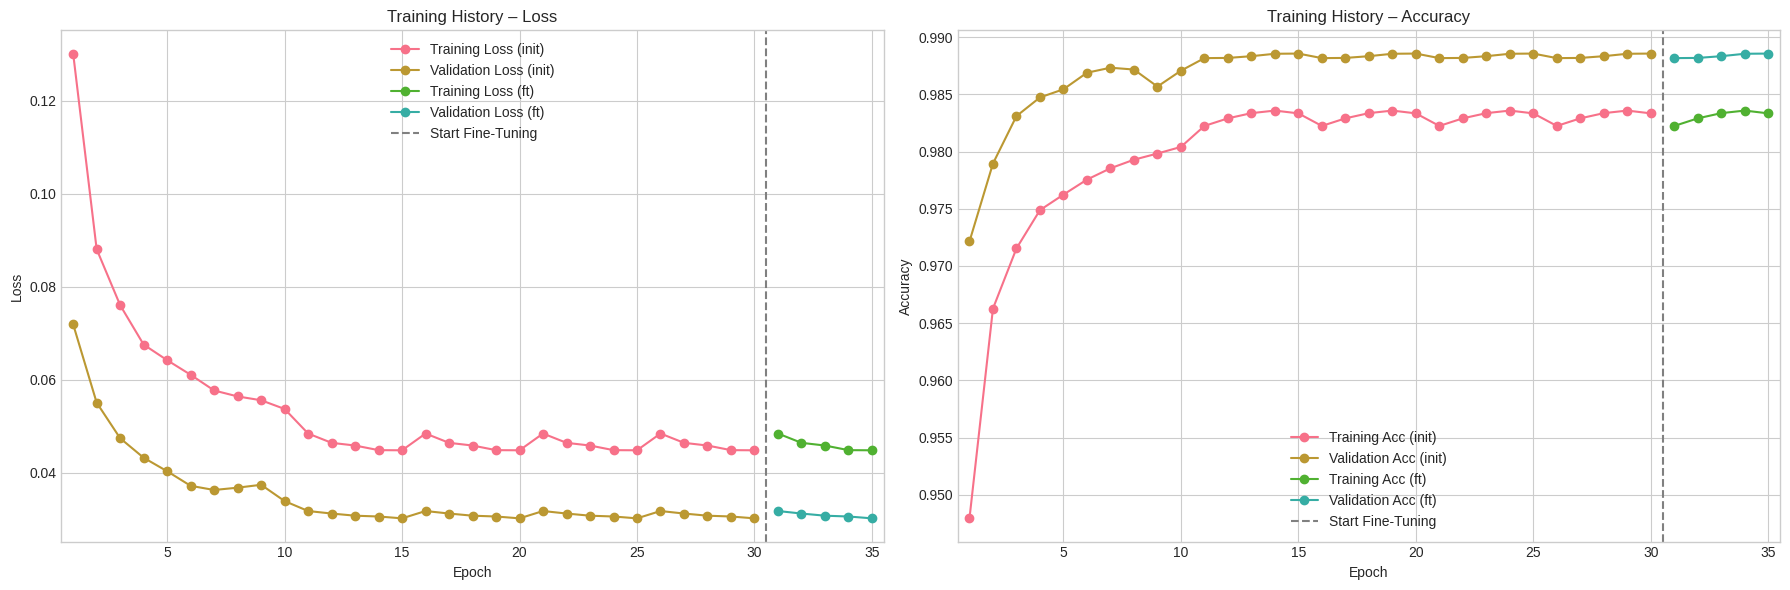

In [58]:
# ==============================================================================
# 6. PLOT RIWAYAT PELATIHAN
# ==============================================================================
print("\nMembuat plot riwayat pelatihan...")
# Panggil fungsi dengan kedua objek history yang sudah kita simpan
plot_training_history(history, history_finetune)


Membuat plot riwayat pelatihan...


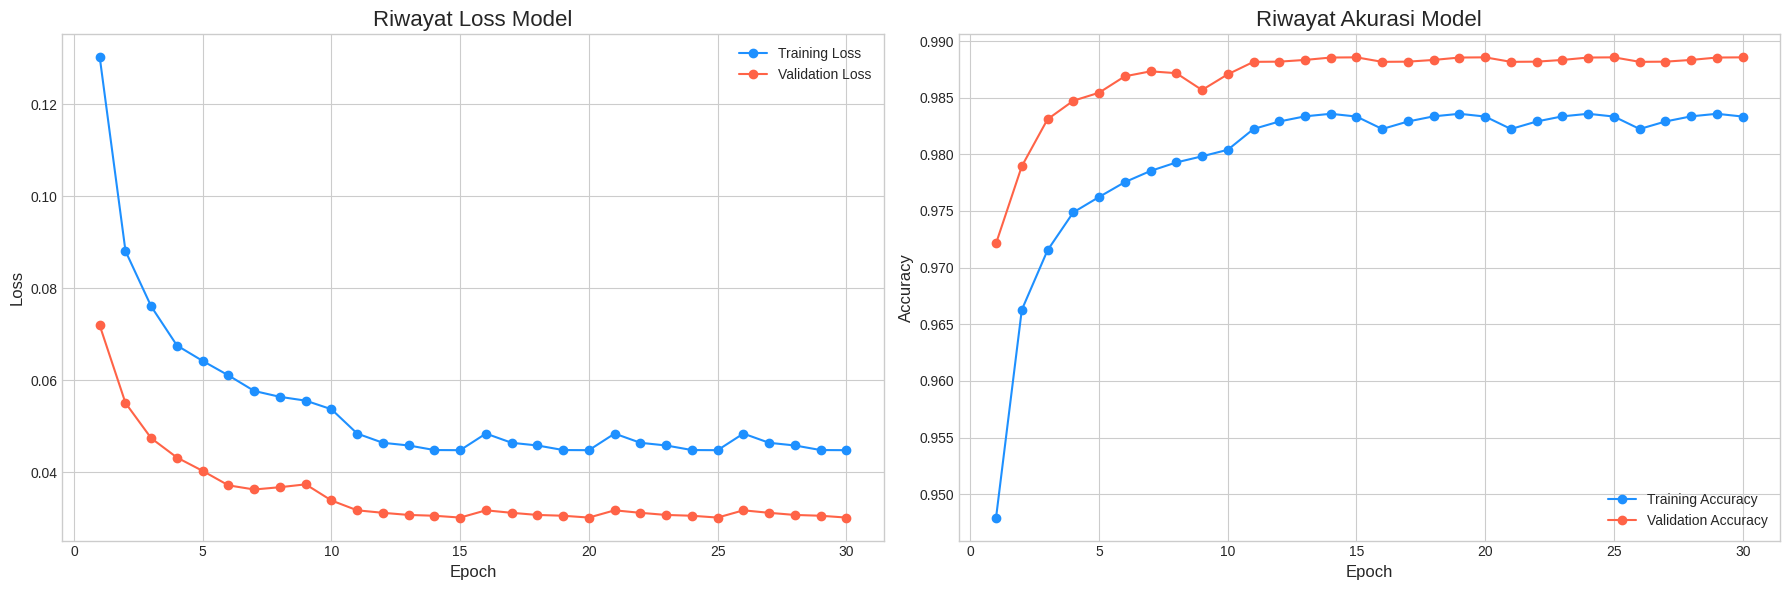

In [52]:
# ==============================================================================
# 6. PLOT RIWAYAT PELATIHAN
# ==============================================================================
print("\nMembuat plot riwayat pelatihan...")
# Panggil fungsi dengan kedua objek history yang sudah kita simpan
plot_training_history(history, history_finetune)


Membuat plot riwayat pelatihan...


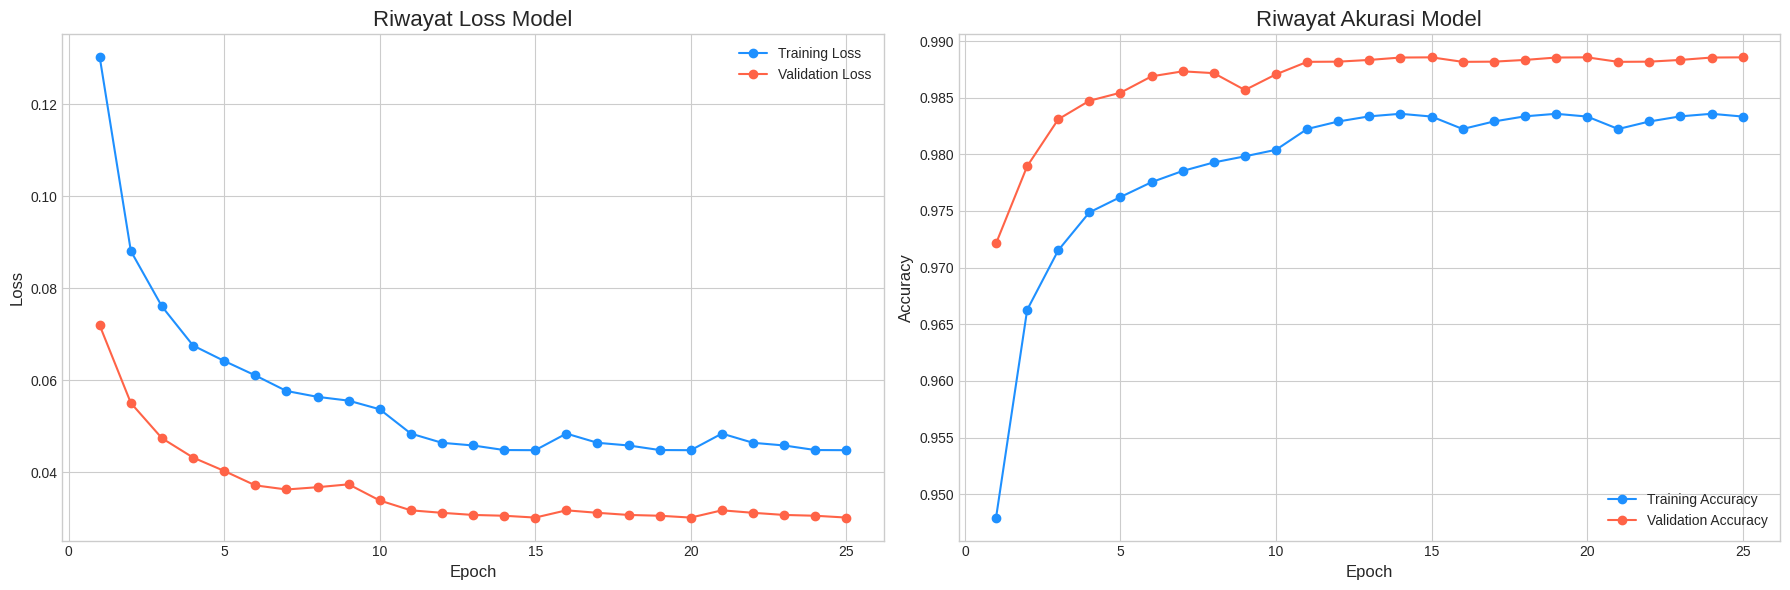

In [51]:
# ==============================================================================
# 6. PLOT RIWAYAT PELATIHAN
# ==============================================================================
print("\nMembuat plot riwayat pelatihan...")
# Panggil fungsi dengan kedua objek history yang sudah kita simpan
plot_training_history(history, history_finetune)

### Evaluasi Hybrid ML


Memuat dan memproses data tes untuk evaluasi...

Mengevaluasi model pada data tes...
4616/4617 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9890 - loss: 0.0297

W0000 00:00:1756772365.516488     121 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


4617/4617 ━━━━━━━━━━━━━━━━━━━━ 263s 57ms/step - accuracy: 0.9890 - loss: 0.0297
Test Loss: 0.0297
Test Accuracy: 0.9888


W0000 00:00:1756772369.421412     123 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


4616/4617 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

W0000 00:00:1756772627.318039     124 assert_op.cc:38] Ignoring Assert operator functional_1/bert_cls_output_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


4617/4617 ━━━━━━━━━━━━━━━━━━━━ 262s 56ms/step

Laporan Klasifikasi:
                                  precision    recall  f1-score   support

                          Normal       0.99      0.99      0.99     98761
                   SQL Injection       0.98      0.99      0.99     47668
           Protocol Manipulation       0.95      0.60      0.74      1214
Dictionary-based Password Attack       0.94      0.89      0.91       100

                        accuracy                           0.99    147743
                       macro avg       0.97      0.87      0.91    147743
                    weighted avg       0.99      0.99      0.99    147743



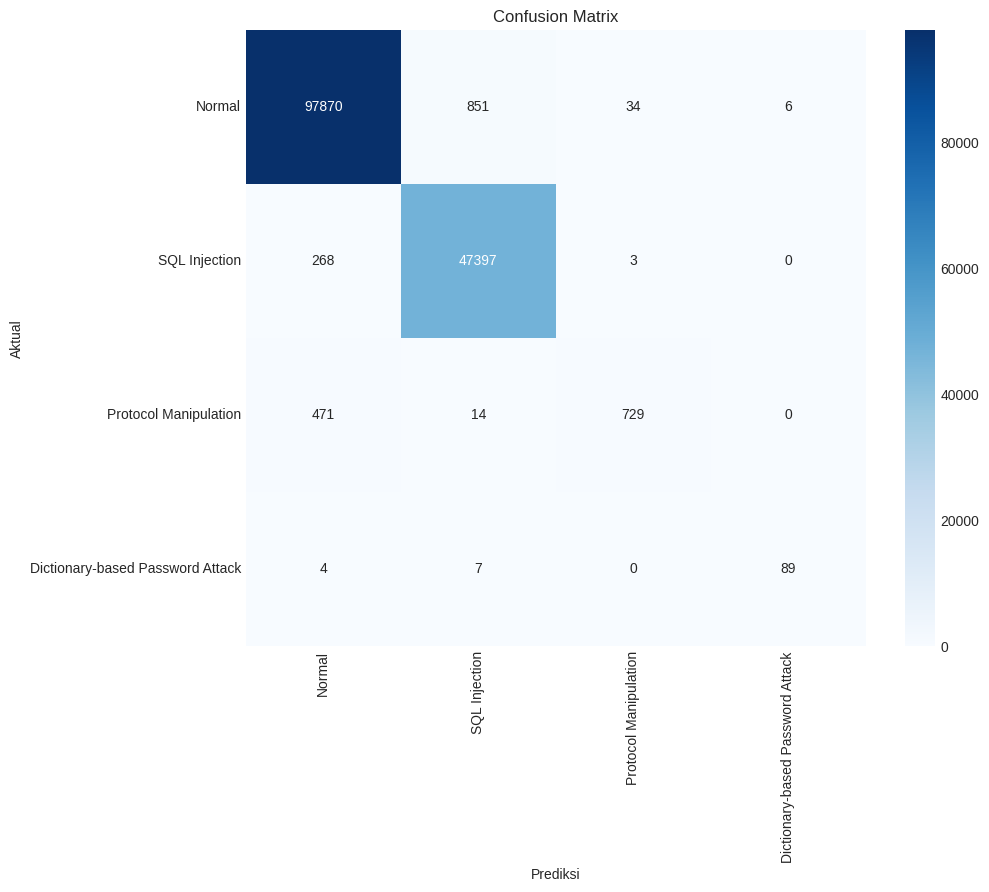

In [46]:
# ==============================================================================
# 7. EVALUASI MODEL PADA DATA TES
# ==============================================================================
print("\nMemuat dan memproses data tes untuk evaluasi...")
df_test = pd.read_csv(TEST_FILE)

# -- Terapkan transformasi yang sama seperti pada data latih --
df_test[categorical_features] = encoder.transform(df_test[categorical_features])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])
df_test[features_to_scale] = df_test[features_to_scale].replace([np.inf, -np.inf], np.nan).fillna(0)

X_test_text = df_test[text_features].fillna('').apply(lambda x: ' '.join(x), axis=1).tolist()
X_test_numcat = df_test[features_to_scale].values

# -- Tokenisasi data tes dengan max_len yang konsisten --
test_encodings = tokenize(X_test_text, max_len=MAX_LEN)

# -- Cek apakah data tes memiliki label --
if target_col in df_test.columns:
    y_test = df_test[target_col].map(label2id).values
    test_dataset = create_dataset(test_encodings, X_test_numcat, y_test).batch(BATCH_SIZE)
    
    print("\nMengevaluasi model pada data tes...")
    test_loss, test_accuracy = model.evaluate(test_dataset)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # -- Laporan Klasifikasi dan Confusion Matrix --
    predictions = model.predict(test_dataset)
    y_pred = np.argmax(predictions, axis=-1)

    print("\nLaporan Klasifikasi:")
    print(classification_report(y_test, y_pred, target_names=id2label.values()))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=id2label.values(), yticklabels=id2label.values())
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title('Confusion Matrix')
    plt.show()

In [47]:
# ==============================================================================
# 7. MENYIMPAN ARTIFACTS (MODEL FINAL, TOKENIZER, SCALER, ENCODER)
# ==============================================================================
print(f"\nMenyimpan semua artifacts ke direktori '{ARTIFACTS_DIR}'...")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# -- Simpan model Keras final --
model.save(os.path.join(ARTIFACTS_DIR, "final_model.keras"))

# -- Simpan tokenizer Hugging Face --
tokenizer.save_pretrained(os.path.join(ARTIFACTS_DIR, "tokenizer"))

# -- Simpan scaler dan encoder --
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "scaler.joblib"))
joblib.dump(encoder, os.path.join(ARTIFACTS_DIR, "target_encoder.joblib"))

# -- Simpan pemetaan label --
with open(os.path.join(ARTIFACTS_DIR, "label_mappings.json"), 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=4)

print("Semua artifacts berhasil disimpan.")


Menyimpan semua artifacts ke direktori 'artifacts'...
Semua artifacts berhasil disimpan.


## Majority Voting

## Inference